In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\user\Desktop\dataset.csv', sep=';', encoding='utf-8', skiprows=2)

df.columns = ['ID', 'Name', 'global_id', 'Photo', 'AdmArea', 'District', 
              'DepartmentalAffiliation', 'Address', 'Capacity', 'ObjectOperOrgName', 
              'ObjectOperOrgPhone', 'Longitude', 'Latitude', 'geoData', 'geodata_center']

df['Capacity'] = df['Capacity'].fillna(df['Capacity'].median())

print("✅ Данные успешно загружены!")
print(f"📊 Формат: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(df.head())

In [4]:
# Задание 1. Подготовка данных

# Загрузка данных (пропускаем только первую строку с описанием)
df = pd.read_csv(r'C:\Users\user\Desktop\dataset.csv', sep=';', encoding='utf-8', skiprows=1)

# Смотрим что получилось
print("Первые 5 строк:")
print(df.head())
print(f"\nНазвания столбцов: {list(df.columns)}")

# Если столбцов 16, то переименовываем их
if len(df.columns) == 16:
    df.columns = ['ID', 'Name', 'global_id', 'Photo', 'AdmArea', 'District', 
                  'DepartmentalAffiliation', 'Address', 'Capacity', 'ObjectOperOrgName', 
                  'ObjectOperOrgPhone', 'Longitude', 'Latitude', 'geoData', 'geodata_center', 'Extra']
else:
    print(f"Столбцов: {len(df.columns)}. Нужно проверить структуру файла")

# Обработка пропусков
df['Capacity'] = pd.to_numeric(df['Capacity'], errors='coerce')
df['Capacity'] = df['Capacity'].fillna(df['Capacity'].median())

# Удаление дубликатов
df = df.drop_duplicates(subset=['ID'])

# Кодирование категориальных переменных
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['AdmArea_encoded'] = le.fit_transform(df['AdmArea'].astype(str))
df['District_encoded'] = le.fit_transform(df['District'].astype(str))

print(f"\nГотово! Формат данных: {df.shape}")

Первые 5 строк:
                        ID                                               Name  \
0  Локальный идентификатор                 Наименование велосипедной парковки   
1                       32    Велосипедная парковка № 37124 «Гимназия № 1506»   
2                       36  Велосипедная парковка № 37106 «Центр образован...   
3                       38        Велосипедная парковка № 37017 «Школа № 263»   
4                       40        Велосипедная парковка № 37061 «Школа № 950»   

   global_id                                 Photo  \
0  global_id                            Фотография   
1    2757725  4b2327b3-55af-4ff1-ab55-786c1d199557   
2    2757729  da0d57c7-03f4-47d7-b7e6-291d87f517bd   
3    2757731  21da1cde-ed77-4508-880a-bf29ff90db84   
4    2757733  9e8b9d52-6939-478e-ae10-20dd9dffd969   

                                   AdmArea                   District  \
0         Административный округ по адресу                      Район   
1  Северо-Восточный админи

Статистика по количеству веломест:
count    1229.000000
mean        6.811229
std         3.957449
min         1.000000
25%         2.000000
50%         8.000000
75%        10.000000
max        24.000000
Name: Capacity, dtype: float64

Среднее количество мест по округам:
AdmArea
Новомосковский административный округ      12.333333
Северо-Восточный административный округ     9.066667
Южный административный округ                8.730263
Юго-Западный административный округ         8.387097
Северо-Западный административный округ      8.048780
Административный округ по адресу            8.000000
Западный административный округ             7.862069
Зеленоградский административный округ       7.400000
Северный административный округ             7.250000
Юго-Восточный административный округ        6.615385
Восточный административный округ            6.231707
Троицкий административный округ             5.454545
Центральный административный округ          4.537736
Name: Capacity, dtype: float64


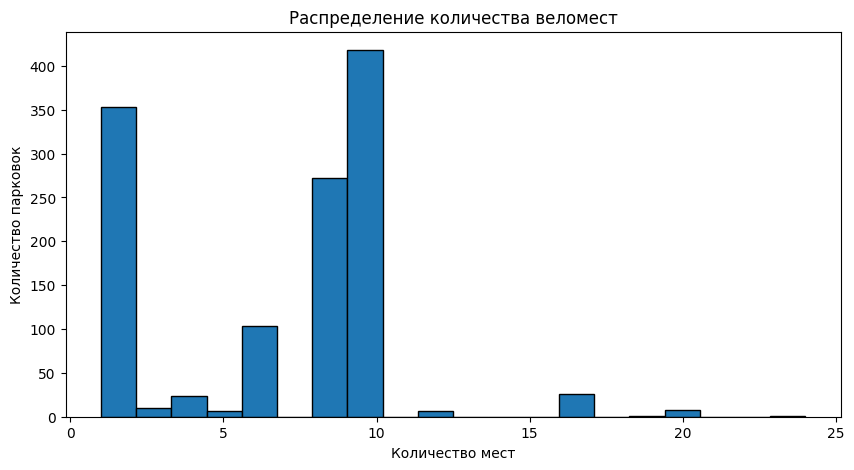

In [5]:
#задание 2
# Статистика по количеству мест
print("Статистика по количеству веломест:")
print(df['Capacity'].describe())

print("\nСреднее количество мест по округам:")
print(df.groupby('AdmArea')['Capacity'].mean().sort_values(ascending=False))

# Простая визуализация
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['Capacity'], bins=20, edgecolor='black')
plt.title('Распределение количества веломест')
plt.xlabel('Количество мест')
plt.ylabel('Количество парковок')
plt.show()

In [10]:
#задание 3
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Подготовка признаков
X = df[['Longitude', 'Latitude', 'AdmArea_encoded', 'District_encoded']]
y = df['Capacity']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Модель обучена")

Модель обучена


In [11]:
#задание 4
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Прогноз на тестовой выборке
y_pred = model.predict(X_test)

# Оценка качества
print("=== ОЦЕНКА КАЧЕСТВА МОДЕЛИ ===")
print(f"R² (коэффициент детерминации): {r2_score(y_test, y_pred):.4f}")
print(f"MAE (средняя абсолютная ошибка): {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Какой признак самый важный
print("\n=== ВАЖНОСТЬ ПРИЗНАКОВ ===")
features = ['Долгота', 'Широта', 'Административный округ', 'Район']
for name, imp in zip(features, model.feature_importances_):
    print(f"{name}: {imp:.4f}")

# Вывод о готовности модели
print("\n=== ВЫВОД ===")
r2 = r2_score(y_test, y_pred)
if r2 > 0.7:
    print("Модель хорошая, можно внедрять")
elif r2 > 0.5:
    print("Модель среднего качества, требуется доработка")
else:
    print("Модель низкого качества, требуется замена алгоритма")

=== ОЦЕНКА КАЧЕСТВА МОДЕЛИ ===
R² (коэффициент детерминации): 0.2371
MAE (средняя абсолютная ошибка): 2.27
RMSE: 3.48

=== ВАЖНОСТЬ ПРИЗНАКОВ ===
Долгота: 0.3199
Широта: 0.4657
Административный округ: 0.0902
Район: 0.1242

=== ВЫВОД ===
Модель низкого качества, требуется замена алгоритма
